# Classification Methods

In [ ]:
%load_ext pretty_jupyter

## Introduction

In this session, we’ll demonstrate how to apply multiple classification techniques to real-world mortgage lending data, exploring how certain borrower attributes (e.g., credit history, debt-to-income ratio, or race) may influence loan approval decisions.We'll use a dataset knwon as [LOANAPP](http://fmwww.bc.edu/ec-p/data/wooldridge/loanapp.des) drawn from by [Hunter and Walker (1996)](https://doi.org/10.1007/BF00174551). In this dataset, each observation corresponds to an individual’s mortgage application, along with various financial and demographic variables. The primary question is whether the applicant’s loan was approved (`approve = 1`) or denied (`approve = 0`).

**What We'll Do Today**

- **Examine the Dataset**: We’ll begin by looking at the structure of the data—what each variable represents, how many observations there are, and whether there are any data issues such as missing values.
  
- **Introduce Classification Models**: We will discuss and implement five classification methods:
  
   - **Linear Probability Model (LPM)**
   - **Logistic Regression (Logit)**
   - **Linear Discriminant Analysis (LDA)**
   - **Naïve Bayes**
   - **Support Vector Machines (SVM)**



- **Fit and Compare**: We’ll split our dataset into training and test subsets, fit each model, and then compare their predictive performance on the test set. We’ll look at standard metrics like accuracy and confusion matrices.

- **Interpretation and Discussion**: While purely predictive metrics are helpful, we will also consider interpretation—especially in a real-world policy or economic context. For instance, does credit history or debt-to-income ratio matter more for approval decisions? How might race or other demographic variables relate to these outcomes?

**What You Will Learn**

- **Data Preparation**: Techniques for reading, cleaning, and exploring data in Python.
- Fundamental **Concepts of Classification**: Understand the core assumptions and interpretations of each classification method (LPM, Logit, LDA, Naïve Bayes, and SVM).
- **Model Evaluation**: How to measure and compare classification performance, including accuracy, confusion matrices, and potentially more nuanced metrics like precision, recall, and ROC curves.
- **Application to Real-World Economic Questions**: You’ll see how classification methods can provide insights into an important public policy issue—mortgage lending—and learn how to interpret results in that context.

By the end of this workshop, you should feel comfortable applying these classification techniques to similar problems, interpreting the outcomes of your models, and understanding the practical trade-offs between different methods.


## Preparing your workfile

In this walkthrough we will use functionality from the following packages:

-` NumPy`: Provides core numerical array operations.
- `pandas`: Handles data import, cleaning, and manipulation.
- `statsmodels`: Allows us to run classical statistical models such as OLS-based Linear Probability Models (LPM) and logistic regressions with more detailed output (e.g., coefficient tables, p-values).
- `scikit-learn`: Includes the train-test split, model evaluation metrics (accuracy, confusion matrices), and classification algorithms (LDA, Naïve Bayes, SVM).
- `lets-plot`: Helps create high-quality, ggplot-style visualizations in Python
 
 > Reminder: Using your  Visual Studio Code (VS Code), you can install these libraries through the Integrated Terminal. First, **Open VS Code** and ensure you have a **Python environment** (interpreter) properly set up. Then, go to **View > Terminal** to open the integrated terminal. In the terminal, run: 

``` python
pip install numpy pandas statsmodels scikit-learn lets-plot
```

Recall that you only need to install the packages once. After ensuring that these are installed you can import the functionality into your code. These libraries will handle everything from data manipulation and modelling to visualization:

In [60]:
import numpy as np                     # Fundamental numerical operations
import pandas as pd                    # Data manipulation & analysis
import statsmodels.api as sm           # For LPM and logistic regression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC            # Support Vector Classifier (SVM)

import matplotlib.pyplot as plt        # Plotting library
from lets_plot import *

# Before using lets_plot, initialize for HTML output (especially if in a notebook or IDE)
LetsPlot.setup_html(no_js=True)

## Loading and explore the data

The dataset we will use in this analysis comes from a **1990 Boston-area mortgage lending study** mandated by the Home Mortgage Disclosure Act of 1975 (HMDA) and subsequently **augmented by the Federal Reserve Bank of Boston**. These data formed the basis of the study in [Hunter and Walker (1996)](https://doi.org/10.1007/BF00174551), which tested an “extended” version of the **cultural affinity hypothesis**.


Broadly, the hypothesis suggests that **loan officers—especially if they lack cultural familiarity with minority applicants—may rely more on observable (objective) signals** like credit history and debt-to-income ratios when evaluating minority applicants. In contrast, loan officers might be more willing to gather or consider additional information for white applicants, thereby mitigating the importance of purely quantitative signals for that group.

### Cleaning and Subset

The original dataset, drawn from the **Boston Fed HMDA** collection, was known for having numerous missing values and coding errors. A careful “cleansing” process removed problematic observations while preserving the overall distribution of borrower characteristics. The **subset** we analyze includes only **conventional mortgage applications** not linked to special housing or lending programs, focusing on typical consumer loans. Despite these restrictions, it remains representative of the core questions around credit access and potential discrimination in lending decisions.

### Economic Rationale

From an **economics of information** standpoint, lenders must **screen** applicants whose true “creditworthiness” is unobservable. They substitute easily observed indicators—like credit history or objective ratios—if they lack deeper familiarity with borrowers. If high-quality borrowers can more easily build reputations (e.g., a history of on-time payments), **lenders will tend to reward those signals**. The crux of the cultural affinity hypothesis is that lenders may apply different thresholds to these signals depending on an applicant’s demographic background.

### Data Exploration 
Our dataset is stored as a Stata file (extension <span style="color:red; font-weight:bold;">.dta</span>). You can load it into a pandas DataFrame and perform initial checks on its structure:


In [6]:
mortgage_data = pd.read_stata("../data/loanapp.dta")

In [13]:
# investigate the shape of the DataFrame (dimensions)
mortgage_data.shape

(1989, 59)

We see that the `DataFrame` has **1,989 observations** (rows) and **59 variables** (columns). This tells us:

1. **Sample Size**: With nearly two thousand individual records, we have a reasonable cross-sectional dataset to analyze mortgage decisions.
2. **Number of Variables**: Having 59 columns suggests the data may include a variety of demographic, financial, and possibly interaction or derived variables, providing a rich set of information to explore in our classification models. 

In [14]:
# Display the first few rows of the dataset
mortgage_data.head()

,occ,loanamt,action,msa,suffolk,appinc,typur,unit,married,dep,...,approve,mortno,mortperf,mortlat1,mortlat2,chist,multi,loanprc,thick,white
0,1,89,1,1120,0,72,0,1.0,0.0,0.0,...,1,0,1,0,0,1,0.0,0.754237,0.0,1
1,1,128,3,1120,0,74,0,1.0,1.0,1.0,...,0,0,1,0,0,1,0.0,0.800000,1.0,1
2,1,128,1,1120,0,84,3,1.0,0.0,0.0,...,1,0,1,0,0,1,0.0,0.895105,1.0,1
3,1,66,1,1120,0,36,0,1.0,1.0,0.0,...,1,0,1,0,0,0,0.0,0.600000,0.0,1
4,1,120,1,1120,0,59,8,1.0,1.0,0.0,...,1,0,1,0,0,1,0.0,0.895522,0.0,1


By default, running the `head()` command will display the first 5 rows of your dataset. However, if you want to specify a different number of rows to display, you can provide that number inside the parentheses. For instance:

``` python
# Display the first 10 rows of the dataset
mortgage_data.head(10)
```

 > You will have noticed that when running a command like `head()` on a large DataFrame, you can see an output where the list of columns or rows is truncated with `....` This happens because Pandas limits the display of rows and columns by default to make the output more manageable.

Now, it would be important to examine the data type that `pandas` has inferred for each column in the dataset. This involves running the  `info()` function.

In [9]:
mortgage_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 59 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   occ       1989 non-null   int8   
 1   loanamt   1989 non-null   int16  
 2   action    1989 non-null   int8   
 3   msa       1989 non-null   int16  
 4   suffolk   1989 non-null   int8   
 5   appinc    1989 non-null   int16  
 6   typur     1989 non-null   int8   
 7   unit      1985 non-null   float64
 8   married   1986 non-null   float64
 9   dep       1986 non-null   float64
 10  emp       1989 non-null   int8   
 11  yjob      1989 non-null   int8   
 12  self      1989 non-null   int8   
 13  atotinc   1989 non-null   float32
 14  cototinc  1989 non-null   float32
 15  hexp      1989 non-null   float32
 16  price     1989 non-null   float32
 17  other     1989 non-null   float32
 18  liq       1989 non-null   float32
 19  rep       1980 non-null   float64
 20  gdlin     1989 non-null   int1

### **Aligning Variables: Mapping the Dataset to the Hunter & Walker Study**

Now that we have explored our dataset using `info()`, we must **compare it with the variables used in the original study** by **Hunter & Walker (1996)**. One of the most crucial steps before conducting any analysis is **ensuring that we are using the correct variables or properly reconstructing them if they are missing or defined differently**.

This is a valuable skill in empirical research: **datasets are not always perfectly structured to match prior studies**, and careful inspection is required. As you can indicate from the [original article](https://doi.org/10.1007/BF00174551), specific variables were used, but **our dataset does not always contain them in the same form**.  Some variables **match exactly**, while others need to be **redefined using available information**.  Without proper alignment, our results might **not be comparable** to the original study.

![Hunter.JPG](../images/Hunter_Tab1.png)


###  Identifying the Best Matching Variables
After reviewing the dataset, you can  identify **the best matches for each key variable** used in the study:

| **Missing Variable** | **What It Represents** | **Best Match in Dataset** | **How to Define It** |
|----------------------|-----------------------|---------------------------|----------------------|
| <span style="color:red;">mhist</span> (Mortgage history) | 1 if ≤2 late mortgage payments | `mortlat1`, `mortlat2` | `mhist = (mortlat1 == 1) & (mortlat2 == 0)` |
| <span style="color:red;">pub</span> (Public record default) | 1 if public record default exists | `pubrec` | No change (`pub = pubrec`) |
| <span style="color:red;">uemp</span> (Unemployment rate by industry) | Probability of unemployment | `unem` | No change (`uemp = unem`) |
| <span style="color:red;">ms</span> (Marital status) | 1 if married, 0 otherwise | `married` | No change (`ms = married`) |
| <span style="color:red;">lnpr</span> (Loan-to-price ratio) | Loan amount / purchase price | `loanprc` | No change (`lnpr = loanprc`) |
| <span style="color:red;">thk</span> (Thickness of credit file) | 1 if >2 credit reports | `thick` | No change (`thk = thick`) |
| <span style="color:red;">arac</span> (Race: 1 if white) | Applicant race indicator | `white` | No change (`arac = white`) |
| <span style="color:red;">asex</span> (Sex: 1 if male) | 1 if male, 0 otherwise | `male` | No change (`asex = male`) |
| <span style="color:red;">loc</span> (condition of local housing market) | 1 if tract vacancy rate is below the MSA median | `vr` | `loc = -vr` |


### **Summary Statistics for Explanatory Variables**

Now that we have explored the structure of our dataset and identified the relevant explanatory variables, let's compute **summary statistics** for these variables. Specifically, we will examine their **mean, standard deviation, minimum, and maximum** values. 

This step is crucial because it helps us understand the distribution of each variable, check for potential outliers, and identify any unexpected values before moving to the classification models.


In [17]:
# Select only the explanatory variables from the dataset
explanatory_vars = ["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thk", "arac", "asex", "loc"]


``` python
# Compute summary statistics (mean, std, min, max)
summary_stats = mortgage_data[explanatory_vars].describe()
```

At this point, when running summary statistics, you may encounter an **error**:

``` python
KeyError: "['mhist', 'pub', 'uemp', 'ms', 'lnpr', 'thk', 'arac', 'asex', 'loc'] not in index"
```

This error message is a **crucial clue** that some variables from the original [Hunter & Walker (1996)](https://doi.org/10.1007/BF00174551) study are **not directly present** in our dataset. Instead of assuming the dataset is complete, we must **investigate the issue** and **find solutions**.

After checking the data variables used in the study of [Hunter & Walker (1996)](https://doi.org/10.1007/BF00174551), we find that **most missing variables exist under different names** or **can be logically derived**. 

 **But here’s the problem:**  
Even though we identified the **best matches for each key variable**, **we haven't actually created the missing variables in Python yet**. Right now, Python still has no idea how to interpret `"pub"`, `"uemp"`, or the other missing variables. For all but `"mhist"` we will merely have to rename the already existing variables to the names indicated in the "Missing Variable" column

In [11]:
mortgage_data.rename(columns={"pubrec": "pub", "unem": "uemp", "married": "ms", "loanprc": "lnpr", 
                              "thick": "thk", "white": "arac", "male": "asex"}, inplace=True)


Only one of the two of the variables need to be calculate, the `"mhist"` and `"loc"` variables.

In [15]:
# Define mhist: 1 if one or two late mortgage payments, 0 otherwise
mortgage_data["mhist"] = ((mortgage_data["mortlat1"] == 1) & (mortgage_data["mortlat2"] == 0)).astype(int)
# Create the missing "loc" variable
mortgage_data["loc"] = 1 - mortgage_data["vr"]

Now, when we re-run summary statistics, the error message should be gone.

In [20]:
# Compute summary statistics (mean, std, min, max)
summary_stats = mortgage_data[explanatory_vars].describe()
summary_stats

,hrat,obrat,mhist,pub,self,chist,uemp,multi,cosign,ms,lnpr,dep,sch,thk,arac,asex,loc
count,1989.000000,1989.000000,1989.000000,1989.000000,1989.000000,1989.000000,1989.000000,1985.000000,1989.000000,1986.000000,1989.000000,1986.000000,1989.000000,1980.000000,1989.000000,1974.000000,1989.000000
mean,24.790915,32.389034,0.019105,0.068879,0.129211,0.837607,3.882303,0.086146,0.028658,0.658610,0.770640,0.770896,0.771745,0.105051,0.845148,0.813070,0.590246
std,7.119459,8.263018,0.136929,0.253312,0.335517,0.368904,2.164130,0.280650,0.166884,0.474295,0.189174,1.104321,0.419814,0.306696,0.361854,0.389954,0.491912
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.021053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,28.000000,0.000000,0.000000,0.000000,1.000000,3.100000,0.000000,0.000000,0.000000,0.700000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
50%,25.770000,33.000000,0.000000,0.000000,0.000000,1.000000,3.200000,0.000000,0.000000,1.000000,0.800000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
75%,29.000000,37.000000,0.000000,0.000000,0.000000,1.000000,3.900000,0.000000,0.000000,1.000000,0.898936,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,72.000000,95.000000,1.000000,1.000000,1.000000,1.000000,10.600000,1.000000,1.000000,1.000000,2.571429,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000



### **Key Takeaway**

- **Never assume that a dataset perfectly matches the variables described in a study**. 

Always:
- **Eyeball the data**: Look at its structure, available variables, and key descriptions.
- **Cross-check with documentation**: Use sources like [loanapp.des](http://fmwww.bc.edu/ec-p/data/wooldridge/loanapp.des) to verify variable definitions.
- **Find smart workarounds**: If a needed variable is missing, ask: *Can I derive it from existing information?*



Below is an overview of  the key variables in this dataset, drawn primarily from Hunter and Walker (1996) [Hunter and Walker (1996)](https://doi.org/10.1007/BF00174551) and verified against our `info()` output. As you can indicate, we have got 17 main explanatory variables plus our dependent variable (`approve`). Each variable is either binary (0/1) or continuous, as indicated:



- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">approve</span> (#49)  
   **Meaning:** 1 if the mortgage application was approved; 0 otherwise.  
   **Relevance:** Dependent variable (outcome of interest).  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">hrat</span> (#25)  
   **Meaning:** Ratio of monthly housing expenses to monthly income (continuous).  
   **Relevance:** Higher values can indicate elevated default risk.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">obrat</span> (#26)  
   **Meaning:** Ratio of total monthly obligations to monthly income (continuous).  
   **Relevance:** Captures overall debt burden; used by lenders to gauge creditworthiness.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">mhist</span> (derived from #52 and #53)  
   **Meaning:** 1 if two or fewer mortgage payments were late, 0 otherwise.  
   **Relevance:** Indicates the applicant’s mortgage payment track record.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">pub</span> (#24)  
   **Meaning:** 1 if a public record default (e.g., bankruptcy) exists, 0 otherwise.  
   **Relevance:** Reflects severe credit history issues that might reduce approval likelihood.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">self</span> (#12)  
   **Meaning:** 1 if the applicant is self-employed, 0 otherwise.  
   **Relevance:** Irregular income for self-employed individuals may raise default risk.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">chist</span> (#54)  
   **Meaning:** 1 if there is no history of delinquent consumer credits, 0 otherwise.  
   **Relevance:** Reflects a “clean” consumer credit track record.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">uemp</span> (#38)  
   **Meaning:** Estimated probability of unemployment by industry (continuous).  
   **Relevance:** Higher values indicate greater job/income instability.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">multi</span> (#55)  
   **Meaning:** 1 if purchasing a two- to four-family property, 0 otherwise.  
   **Relevance:** Multi-unit properties can add complexity to the lending decision.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">cosign</span> (#34)  
    **Meaning:** 1 if a co-signer is present, 0 otherwise.  
    **Relevance:** A co-signer may reduce the perceived risk of default.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">ms</span> (#8)  
    **Meaning:** 1 if the applicant is married, 0 otherwise.  
    **Relevance:** Marriage might imply shared income and reduced risk.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">lnpr</span> (#56)  
    **Meaning:** Loan-to-price ratio (continuous).  
    **Relevance:** Analogous to loan-to-value; signals borrower equity.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">dep</span> (#9)  
    **Meaning:** Number of dependents (integer).  
    **Relevance:** More dependents often mean higher living expenses.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">sch</span> (#44)  
    **Meaning:** 1 if the applicant has more than 12 years of education, 0 otherwise.  
    **Relevance:** Education level may correlate with higher earning potential.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">thk</span> (#57)  
    **Meaning:** 1 if there are more than two credit reports in the file, 0 otherwise.  
    **Relevance:** A “thick” credit file could indicate a robust borrowing history.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">arac</span> (#58)  
    **Meaning:** 1 if the applicant is white, 0 otherwise.  
    **Relevance:** Central to the cultural affinity hypothesis examining race-based screening.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">asex</span> (#47)  
    **Meaning:** 1 if the applicant is male, 0 otherwise (female or info missing).  
    **Relevance:** Allows investigation of gender effects on mortgage approval.  

- <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">loc</span> (derived from #43)  
    **Meaning:** 1 if the tract vacancy rate is smaller than the MSA median, 0 otherwise.  
    **Relevance:** Suggests a “better” neighborhood location, potentially boosting approval odds.  


Therefore, the summary statistics for the key explanatory variables are:

In [24]:
# Select only the explanatory variables from the dataset
explanatory_vars = ["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thk", "arac", "asex", "loc"]

# Compute summary statistics (mean, std, min, max)
summary_stats = mortgage_data[explanatory_vars].describe().T[["count", "mean", "std", "min", "max"]]

# Display the summary statistics
print(summary_stats)

         count       mean       std       min        max
hrat    1989.0  24.790915  7.119459  1.000000  72.000000
obrat   1989.0  32.389034  8.263018  0.000000  95.000000
mhist   1989.0   0.019105  0.136929  0.000000   1.000000
pub     1989.0   0.068879  0.253312  0.000000   1.000000
self    1989.0   0.129211  0.335517  0.000000   1.000000
chist   1989.0   0.837607  0.368904  0.000000   1.000000
uemp    1989.0   3.882303  2.164130  1.800000  10.600000
multi   1985.0   0.086146  0.280650  0.000000   1.000000
cosign  1989.0   0.028658  0.166884  0.000000   1.000000
ms      1986.0   0.658610  0.474295  0.000000   1.000000
lnpr    1989.0   0.770640  0.189174  0.021053   2.571429
dep     1986.0   0.770896  1.104321  0.000000   8.000000
sch     1989.0   0.771745  0.419814  0.000000   1.000000
thk     1980.0   0.105051  0.306696  0.000000   1.000000
arac    1989.0   0.845148  0.361854  0.000000   1.000000
asex    1974.0   0.813070  0.389954  0.000000   1.000000
loc     1989.0   0.590246  0.49

An important observation we can make from the `summary` function is that **missing values** are present in the `asex`, `thk`, `multi`, `ms` and `dep` variables, which could impact downstream analysis and, therefore, would need careful handling. Let's now calculate the **number and percentage of missing values** for each of these columns. 

In [26]:
# Calculate missing values for 'asex' and 'thick'
missing_values = mortgage_data[['asex', 'thk','multi', 'ms','dep']].isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(mortgage_data)) * 100

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display the summary
print(missing_summary)

       Missing Values  Percentage (%)
asex               15        0.754148
thk                 9        0.452489
multi               4        0.201106
ms                  3        0.150830
dep                 3        0.150830


We can also ask how many of the observations in `mortgage_data` have any piece of missing information.

In [27]:
# Count rows with any missing values
missing_rows = mortgage_data.isnull().any(axis=1).sum()

# Get total percentage of rows with missing values
missing_percentage = (missing_rows / len(mortgage_data)) * 100

print(f"Number of rows with missing values: {missing_rows}")
print(f"Percentage of rows with missing values: {missing_percentage:.2f}%")

Number of rows with missing values: 211
Percentage of rows with missing values: 10.61%


Since these missing values are relatively low, we need to decide on a handling strategy.  There are three popular schemes that deal with missing values:

1. **Delete observations/rows with missing values**: This course of action implies that we would remove more than 10% of observations.
2. **Keep the missing values**, because they might be meaningful.
3. **Replace (Impute)**: This involves replacing the missing value with a known value.


> For a thorough understanding of handling  missing values and mastering data mining techniques the following resources offer valuable insights:
> - [Berry and Linoff (2004)](https://pzs.dstu.dp.ua/DataMining/bibl/Data%20Mining%20Techniques%20For%20Marketing%20Sales%20And%20Customer%20Relationship%20Management%202Ed.pdf),
> - [Wilet et al. (2020)](https://link.springer.com/article/10.1007/s11336-022-09856-8)
> -  [Coding  for Economists by Arthur Turrell](https://aeturrell.github.io/coding-for-economists/intro.html)

When working with real-world data, missing values are common, and handling them appropriately is crucial to ensure a useful analysis. There are multiple imputation techniques available to deal with missing values, including:

- **Mean/Median Imputation** (for continuous variables)
- **Mode Imputation** (for categorical variables)
- **Multiple Imputation** (advanced statistical methods)
- **Predictive Modeling-Based Imputation** (e.g., k-Nearest Neighbors, Decision Trees)
However, a deep dive into different imputation methods is beyond the scope of this workshop. For simplicity, we will use mode imputation, which is a standard and commonly used approach for handling missing values in binary categorical variables.

Since `asex`, `thk`, `multi`, `ms` and `dep` are binary variables (`0 or 1`), the most frequently occurring value (**mode**) represents the most likely category.

## Applying Mode Imputation

We will replace the missing values in `asex`, `thk`, `multi`, `ms` and `dep` with their respective mode (the most frequently occurring value in each column):


In [33]:
# Fill missing values with the most common value (mode)
mortgage_data['asex'] = mortgage_data['asex'].fillna(mortgage_data['asex'].mode()[0])
mortgage_data['thk'] = mortgage_data['thk'].fillna(mortgage_data['thk'].mode()[0])
mortgage_data['multi'] = mortgage_data['multi'].fillna(mortgage_data['multi'].mode()[0])
mortgage_data['ms'] = mortgage_data['ms'].fillna(mortgage_data['ms'].mode()[0])
mortgage_data['dep'] = mortgage_data['dep'].fillna(mortgage_data['dep'].mode()[0])

Now, lets look again at the percentage of missing values for these specific variables:

In [34]:
# Calculate missing values for 'asex' and 'thick'
missing_values = mortgage_data[['asex', 'thk','multi', 'ms','dep']].isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(mortgage_data)) * 100

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display the summary
print(missing_summary)

       Missing Values  Percentage (%)
asex                0             0.0
thk                 0             0.0
multi               0             0.0
ms                  0             0.0
dep                 0             0.0


Now that we have no more missing values for `asex`, `thk`, `multi`, `ms` and `dep`, we have successfully handled them using mode imputation, which preserves the most frequently occurring category. While more advanced imputation techniques exist, mode imputation is a simple and effective approach within the scope of this workshop. With no missing values, we can now proceed with further analysis.

> Note that there are still missing values in other variables, but these are variables we will not use in the further analysis.

# **Classification Models**

Now, we are ready to apply and compare various **classification models** to predict **mortgage loan** approvals. Our goal is to determine how well different statistical techniques can classify whether a mortgage application is **approved (1)** or **denied (0)** based on borrower characteristics.

### Why Classification Models? 

Mortgage approval decisions are inherently **binary outcomes**—either an applicant is approved or not. This makes classification models ideal for the task. Classification models assign **probabilities** to different outcomes and allow us to analyze the key factors affecting lending decisions.

We will use the following models:

1. Linear Probability Model (LPM)
2. Logistic Regression (Logit)
3. Linear Discriminant Analysis (LDA)
4. Naïve Bayes
5. Support Vector Machines (SVM)


# **Mathematical Framework: The Dichotomous Choice Model**

Hunter & Walker (1996) framed mortgage approval decisions using **dichotomous choice models**—where an applicant is granted or denied a mortgage based on an underlying measure of creditworthiness.

We assume that each applicant $ k $ has an **unobserved creditworthiness index**, $ I_k $, which is a linear function of explanatory variables:

$$
I_k = X_k \beta + \epsilon_k
$$

where:

- $X_k$ is a vector of explanatory variables (e.g., credit history, debt-to-income ratio).
- $β$ is the parameter vector to be estimated.
- $\epsilon_k $ is an error term capturing unobserved factors.

Since we **do not directly observe $I_k$**, we only see whether the application was approved:

$$
Y_k =
\begin{cases} 
1, & \text{if } I_k > 0 \quad (\text{Approved}) \\
0, & \text{otherwise} \quad (\text{Denied})
\end{cases}$$

The probability that a mortgage is approved can be written as:

$$
P(Y_k = 1) = F(X_k \beta)
$$

where $ F(.) $ is a **cumulative distribution function (CDF)**. The choice of $F(.)$ defines the classification model:

- **Linear Probability Model (LPM):** $ F(X_k \beta) $ is simply linear.
- **Logistic Regression (Logit):** $F(X_k \beta)$ follows the logistic function.
- **Linear Discriminant Analysis (LDA):** Uses Bayes’ theorem assuming normally distributed predictors.
- **Naïve Bayes:** Similar to LDA but assumes independence between predictors.
- **Support Vector Machine (SVM):** Uses a hyperplane to separate approved and denied loans.

Now, let’s explore each model in detail.


## Linear Probability Model (LPM)


The **Linear Probability Model (LPM)** is the simplest method, where we estimate a standard **Ordinary Least Squares (OLS)** regression but interpret the dependent variable as a probability.

$$
P(Y_k = 1 \mid X_k) = X_k \beta + \epsilon_k
$$

where:

- $ X_k $ are explanatory variables.
- $ \beta$ are coefficients estimated using OLS.

The LPM assumes a **linear relationship** between explanatory variables and the probability of approval. However, this model has key limitations:

- **Predicted probabilities can be outside the [0,1] range.**
- **Heteroskedasticity:** The error term $ \epsilon_k $ has non-constant variance by construction .
- **Non-normality of errors:** Violates OLS assumptions.

Despite these drawbacks, the LPM is useful as a baseline model for comparison with nonlinear probability models such as Logit and Probit.
 

In [37]:
import statsmodels.api as sm

# Define explanatory variables and response variable
X = mortgage_data[["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thk", "arac", "asex", "loc"]]
y = mortgage_data["approve"]

# Add constant term
X = sm.add_constant(X)

# Fit LPM using OLS
lpm_model = sm.OLS(y, X).fit()

# Display summary
print(lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                approve   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     23.43
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           5.82e-67
Time:                        20:07:38   Log-Likelihood:                -422.42
No. Observations:                1989   AIC:                             880.8
Df Residuals:                    1971   BIC:                             981.6
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9186      0.052     17.583      0.0

Now that we have estimated the **Linear Probability Model (LPM)** using **Ordinary Least Squares (OLS)**, let's analyze the results in relation to **mortgage approval**.

###  Model Fit and Overall Significance
- **R-squared = 0.168**: What does this tell us?
- **F-statistic = 23.43 (p-value ≈ 0.000)**: Is the overall model statistically significant?


### Key Coefficients and Interpretation


The estimated coefficients represent **changes in the probability of mortgage approval** for **a one-unit increase** in each explanatory variable.

Is the above statement **correct?**

Looking  at the results, discuss and interpret the significant variables, keeping in mind that all interpretations are ceteris paribus (i.e. everything else staying equal):


| **Variable**                     | **Coefficient** | **p-value** | **Interpretation** |
|----------------------------------|---------------|------------|--------------------|
| **Intercept**                    | 0.9186        | 0.000      | no sensible interpretation. |
| **obrat (Debt-to-Income Ratio)**  | -0.0054       | 0.000      | A **1 percentage point increase** in debt burden **reduces the probability of approval by 0.54%**. |
| **pub (Public Record Default)**   | -0.2359       | 0.000      | Having a **public record default** (e.g., bankruptcy) **reduces approval probability by 23.6%**. |
| **self (Self-employed)**          | -0.0428       | 0.038      | **Self-employed applicants** are **4.3% less likely** to be approved compared to non-self-employed applicants. |
| **chist (Clean Credit History)**  | +0.1351       | 0.000      | A **clean credit history** **increases approval probability by 13.5%**. |
| **multi (Multi-unit Purchase)**   | -0.0714       | 0.004      | Purchasing a **multi-unit property** **lowers approval probability by 7.1%**. |
| **ms (Married)**                  | +0.0441       | 0.006      | **Married applicants** are **4.4% more likely** to be approved. |
| **lnpr (Loan-to-Price Ratio)**    | -0.1401       | 0.000      | A **higher loan-to-price ratio** (more financing required relative to price) **lowers approval probability by 14%**. |
| **arac (White Applicant)**        | +0.1202       | 0.000      | **White applicants have a 12% higher probability** of approval, supporting the **cultural affinity hypothesis**. |
| **loc (Better Neighborhood)**     | +0.0281       | 0.044      | Buying in a **lower-vacancy area** **increases approval probability by 2.8%**. |

### **Key Takeaways**
- **Debt burden, public defaults, and higher loan-to-price ratios negatively impact approval probabilities.**
- **Credit history and marital status have positive effects on mortgage approval.**
- **Evidence supports the cultural affinity hypothesis, with white applicants having a statistically significant advantage.**
- **The location of the property plays a role, with better neighbourhoods increasing approval odds.**


On the contrary, looking at the insignificant variables (not statistically significant), which result seems to aligh with Hunter and Walker's findings?

 <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: The fact that gender (`asex`) is insignificant aligns with Hunter & Walker’s findings: mortgage approval rates do not significantly differ by gender.


### Model Limitations

- **Predicted probabilities** can be < 0 or > 1, which is unrealistic.
- **Heteroskedasticity** is a concern, as residual variance depends on the explanatory variables.
- **Non-linearity of probabilities**: The Logit model, which we estimate next, fixes these issues by ensuring probabilities are between 0 and 1.

## Evaluating the Linear Probability Model (LPM)

Since LPM uses **Ordinary Least Squares (OLS)**, it does not directly output classification probabilities but rather estimates probabilities that can be greater than 1 or less than 0. To evaluate its performance as a classification model, we need to:

1. Convert LPM predictions into binary classifications (e.g. using a threshold at 0.5, probabilities higher than this threshold predict the approval of a mortgage).
2. Calculate accuracy by comparing predicted and actual values.
3. Compute AUC-ROC to see how well the model distinguishes between approved vs. denied applicants.

### Step 1:  Predict Using the LPM

In [50]:
import matplotlib.pyplot as plt

# Get predicted probabilities from LPM
y_pred_lpm_probs = lpm_model.predict(X)

# Convert probabilities to binary outcomes (threshold = 0.5)
y_pred_lpm = np.where(y_pred_lpm_probs >= 0.5, 1, 0)


### Step 2: Plot AUC-ROC Curve for LPM

In order to evaluate the forecast performance and ultimately compare the forecasting performance to that of other models, we use the following measures


 1. **Generate a Confusion Matrix**:
A confusion matrix compares the predicted and actual approval statuses to evaluate model performance. It is structured as:

| Actual \ Predicted | Approved (1) | Not Approved (0) |
|--------------------|-------------|-----------------|
| **Approved (1)**  | True Positives (TP) | False Negatives (FN) |
| **Not Approved (0)** | False Positives (FP) | True Negatives (TN) |

 2. **Compute Model Accuracy**:
The accuracy (proportion of correctly classified observations) of the model is calculated as:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

 3. **Plot AUC-ROC Curve**
The **Receiver Operating Characteristic (ROC) curve** evaluates the model's ability to distinguish between approved and not approved applicants. The **Area Under the Curve (AUC-ROC)** measures the model’s discriminatory power:

- **AUC = 1** → Perfect classifier.
- **AUC = 0.5** → No discrimination (random classification).
- **Higher AUC** → Better model performance.

The ROC curve plots **True Positive Rate (Sensitivity)** against **False Positive Rate (1 - Specificity)** at different classification thresholds.


In [ ]:
# Calculate accuracy
lpm_accuracy = accuracy_score(y, y_pred_lpm)

# Generate confusion matrix
lpm_conf_matrix = confusion_matrix(y, y_pred_lpm)

# Compute AUC-ROC
lpm_auc = roc_auc_score(y, y_pred_lpm_probs)

# Print results
print(f"Linear Probability Model (LPM) Accuracy: {lpm_accuracy:.4f}")
print(f"Confusion Matrix:\n{lpm_conf_matrix}")
print(f"LPM AUC-ROC Score: {lpm_auc:.4f}")

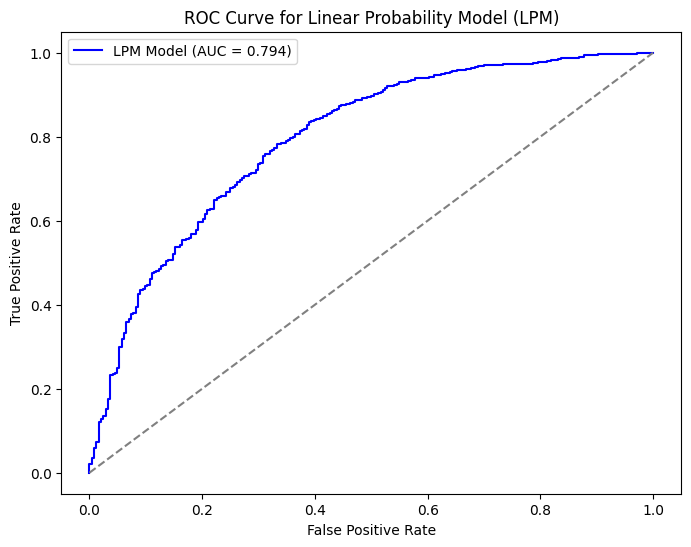

In [44]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_lpm_probs)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", label=f"LPM Model (AUC = {lpm_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Linear Probability Model (LPM)")
plt.legend()
plt.show()

The ROC curve for the Linear Probability Model (LPM) illustrates its ability to distinguish between approved and denied mortgage applications. The **AUC score of 0.794** suggests a **moderate predictive ability**, meaning the model performs better than random guessing (AUC = 0.5) but does not achieve high classification performance. The curve rises significantly above the diagonal reference line, indicating useful discriminatory power.
However, LPM's main limitation lies in its **unbounded probability predictions** (which can sometimes be below 0 or above 1) and its assumption of a **linear relationship** between the predictors and approval probabilities. While LPM provides interpretability, its performance suggests that more sophisticated models, such as logistic **regression or LDA**, may be better suited for classification in this context.

##  Logistic Regression (logit)


The **Logit model** is a widely used classification technique for binary dependent variables (e.g., mortgage approval: **approve = 1 or 0**). Unlike the **Linear Probability Model (LPM)**, which can produce probabilities **less than 0 or greater than 1**, the Logit model ensures that predicted probabilities remain **between 0 and 1**.


The **Logit model** assumes that the probability of an event occurring follows a sigmoid (S-shaped) function, known as the **logistic function**:

$$
P(Y_k = 1) = \frac{1}{1 + e^{-X_k \beta}}
$$

where:

- $ P(Y_k = 1) $ is the probability that the **mortgage application is approved** (our dependent variable).
- $ X_k $ is the **vector of explanatory variables** (e.g., credit history, debt ratio, income, etc.).
- $ \beta $ is the **vector of coefficients** we estimate.

Advantage of this approach are:

- **Ensures probabilities remain between 0 and 1.**  
- **Accounts for non-linearity**, meaning the effect of explanatory variables **is not constant** across all values of $ X_k $.  

### Log-Odds Transformation (Logit Function)
Instead of modeling $ P(Y_k = 1) $ directly, we **transform** it using the **log-odds (logit) function**:

$$
\ln \left( \frac{P(Y_k = 1)}{1 - P(Y_k = 1)} \right) = X_k \beta
$$

This transformation allows us to interpret the relationship between mortgage approval and explanatory variables in terms of **odds ratios**, making it useful for understanding factors influencing loan approval decisions.

### How Can we interpret the odds ratio?

Logit model coefficients help us understand how each variable affects the **odds of mortgage approval**. The **odds ratio** for a variable $x_i $ is calculated as:

$$
\text{Odds Ratio} = e^{\beta_i}
$$

### **Interpretation:**
- If $ e^{\beta_i} > 1 $, the variable **increases** the odds of approval.
- If $ e^{\beta_i} < 1 $, the variable **decreases** the odds of approval.
- If $ e^{\beta_i} = 1 $, the variable **has no effect** on approval odds.


What does it mean if the odds ratio for **public record default** was **0.40**?

What does it mean if the odds ratio for **marital status** was **1.30** ?

 <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: If the odds ratio for public record default is 0.40, an applicant with a public record is **60%** less likely to be approved compared to someone without one.

 <span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>:  married applicants are **30% more likely** to be approved than unmarried applicants. (_Since 1.30 - 1 = 0.30 or 30% increase in odds._)


In [ ]:
# Define explanatory variables and response variable
# as previously defined
X = mortgage_data[["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                   "cosign", "ms", "lnpr", "dep", "sch", "thk", "arac", "asex", "loc"]]
y = mortgage_data["approve"]

# Add constant term
X = sm.add_constant(X)

# Fit the Logit model
logit_model = sm.Logit(y, X).fit()

# Display summary
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.301165
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                approve   No. Observations:                 1989
Model:                          Logit   Df Residuals:                     1971
Method:                           MLE   Df Model:                           17
Date:                Tue, 04 Nov 2025   Pseudo R-squ.:                  0.1909
Time:                        20:44:29   Log-Likelihood:                -599.02
converged:                       True   LL-Null:                       -740.35
Covariance Type:            nonrobust   LLR p-value:                 4.214e-50
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5244      0.591      5.963      0.000       2.366       4.683
hrat           0.0124      0.

Looking at Key Model Fit Statistics we can indicate that the the **log-likelihood** of -599.02 suggests the overall fit of the model, with higher absolute values indicating better performance. The **pseudo R²** of 0.1909, which is the Logit model's equivalent of R² in linear regression, suggests the model has **moderate explanatory power**. Additionally, the **Likelihood Ratio (LR) p-value** of **4.214e-50** provides strong statistical evidence that the model significantly improves prediction over a null model which does not include any explanatory variables.

### Coefficient Interpretation

Since Logit is a **non-linear** model, coefficients are interpreted in terms of **log-odds** rather than marginal effects on probability.

A **positive** coefficient means the variable **increases** the likelihood of mortgage approval, while a **negative** coefficient decreases it.


| Variable       | Coefficient | Interpretation with Solution |
|---------------|-------------|-----------------------------------------------------------|
| **Intercept (const)** | 3.5244 | no sensible interpretation. |
| **hrat** | 0.0124 | Insignificant, meaning housing expense ratio does not strongly influence approval. |
| **obrat** | -0.0525 | Higher debt-to-income ratio reduces approval probability (statistically significant). |
| **mhist** | -0.2602 | Mortgage history (late payments) does not have a strong effect (p = 0.575). |
| **pub** | -1.3157 | Strong negative effect: Public record defaults (e.g., bankruptcy) substantially reduce approval likelihood. |
| **self** | -0.5206 | Self-employment reduces approval probability—likely due to income volatility. |
| **chist** | 1.1185 | Clean credit history significantly increases approval chances. |
| **uemp** | -0.0569 | Probability of unemployment has a small, weakly negative effect. |
| **multi** | -0.4714 | Multi-unit properties lower approval probability, possibly due to financing complexities. |
| **cosign** | 0.2271 | Insignificant effect of having a co-signer (p = 0.621). |
| **ms** | 0.5187 | Being married increases mortgage approval chances. |
| **lnpr** | -1.8679 | High loan-to-price ratio greatly reduces approval probability—suggests risk aversion by lenders. |
| **dep** | -0.1075 | Having more dependents slightly reduces approval probability, but not significantly. |
| **sch** | 0.0327 | Education does not significantly impact approval decisions. |
| **thick** | 0.0106 | The number of credit reports does not have a strong effect. |
| **arac** | 0.8912 | White applicants have a significantly higher approval probability. |
| **asex** | -0.0612 | Gender does not play a significant role. |
| **loc** | 0.3248 | Living in a lower-vacancy tract increases approval chances. |

## Key **Takeaways**

- **Debt-to-income ratio (obrat)** and **loan-to-price ratio (lnpr)** are key financial indicators affecting approval negatively.
- **Public record defaults (pub)** and **self-employment (self)** significantly reduce approval likelihood.
- **Clean credit history (chist)** and **marital status (ms)** are strong positive predictors.
- **Race (arac)** shows that white applicants have a statistically higher chance of approval.
- **Education (sch)** and **gender (asex)** do not appear to significantly influence approval decisions.

Compare now the results with the LPM results.

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>:  
- The results are similar:  Debt burden (`obrat`), public record defaults (`pub`), credit history (`chist`), and marital status (`ms`) have similar effects in both models.
- **Different effects**: The impact of some variables (like `loc`) is stronger in Logit.
- **Improved probability constraint**: Unlike LPM, Logit ensures predicted probabilities stay between 0 and 1.


You are now in a place to evaluate the Logit Model

### Evaluate the Logit Model

The steps to evaluate the logit model consist off:

We use the fitted logistic regression model to predict the probability of mortgage approval for each applicant:

$$
P(\hat{Y}) = \frac{1}{1 + e^{-X\beta}}
$$

where:
- $ P(\hat{Y}) $ is the predicted probability of approval.
- $ X $ is the matrix of explanatory variables.
- $ \beta $ represents the estimated coefficients from the Logit model.

As for the linear probability model, in order to evaluate these classification predictions (either approved, 1, or not approved, 0), we apply a threshold (note that one could use other thresholds too at this step.):

$$
\hat{Y} =
\begin{cases}
1, & P(\hat{Y}) > 0.5 \quad \text{(Approved)} \\
0, & P(\hat{Y}) \leq 0.5 \quad \text{(Not Approved)}
\end{cases}
$$
    
We use the same evaluation tools as earlier, the confusion matrix, the model accuracy and the  AUC-ROC Curve.

Logit Model Accuracy: 0.8869

🔹 Confusion Matrix:
[[  47  197]
 [  28 1717]]


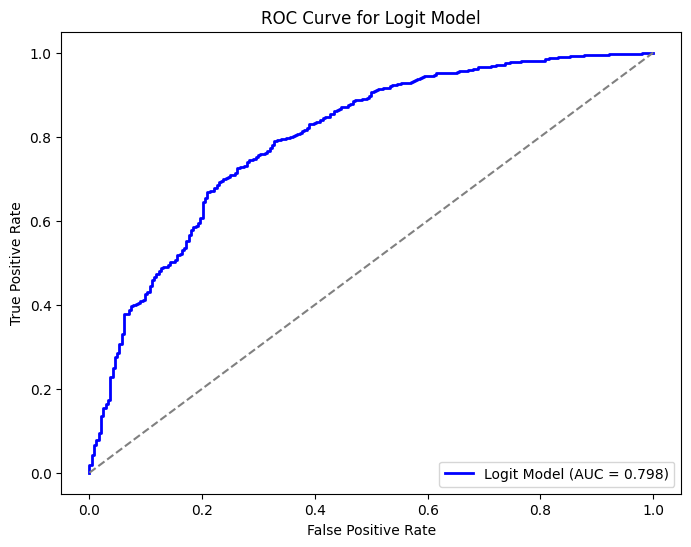

In [54]:
# Predict probabilities using the fitted Logit model
y_pred_probs = logit_model.predict(X)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

# Compute confusion matrix
conf_matrix = confusion_matrix(y, y_pred_binary)

# Compute model accuracy
accuracy = accuracy_score(y, y_pred_binary)

# Calculate the AUC-ROC Curve
fpr, tpr, _ = roc_curve(y, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Display results
print(f"Logit Model Accuracy: {accuracy:.4f}")
print("\n🔹 Confusion Matrix:")
print(conf_matrix)

# Plot AUC-ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logit Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logit Model")
plt.legend(loc="lower right")
plt.show()


We can indicate that the **model accuracy** is 88.69%. This tells us that the Logit model correctly predicts mortgage approval **88.69%** of the time. This is **relatively high**, indicating that the model performs well.

#### Confusion Matrix

On the other hand, the confusion matrix provides a breakdown of how well our logistic regression model classifies mortgage applications into "Approved" (1) and "Not Approved" (0).


| **Actual \ Predicted**  | **Predicted: Not Approved (0)** | **Predicted: Approved (1)** |
|-------------------------|--------------------------------|----------------------------|
| **Actual: Not Approved (0)**  | 47 (True Negative)  | 197 (False Positive)  |
| **Actual: Approved (1)**  | 28 (False Negative)  | 1717 (True Positive)  |

##### **Interpretation of Results**

- **True Positives (TP = 1717)**: Approved applications that were correctly predicted as approved.
- **True Negatives (TN = 47)**: Denied applications that were correctly predicted as denied.
- **False Positives (FP = 197)**: Applications incorrectly predicted as approved when they were actually denied.
- **False Negatives (FN = 28)**: Applications incorrectly predicted as denied when they were actually approved.

##### **Key Insights**
- The model performs well in correctly identifying approved applications, with **1717 true positives**.
- However, **197 applications were falsely classified as approved**, leading to potential risks in lending decisions.
- The number of **false negatives (28) is relatively low**, meaning the model does not deny many applicants who should be approved.
- The **true negative count (47) is low**, suggesting that most applications are predicted as approved rather than denied.

####  AUC (Area Under the Curve) Score
The AUC-ROC curve is a crucial metric for evaluating the model’s ability to distinguish between **approved** and **denied** mortgage applications. We can indicate that the score is** 0.798**

#####  **Understanding AUC Values**
- **AUC = 0.5** → No discrimination (random guessing).
- **AUC = 1.0** → Perfect classifier.
- **AUC = 0.798** → The model has **good discriminatory power**, meaning it correctly distinguishes between approvals and denials in **79.8% of cases**. However, there is still room for improvement.

####  ROC Curve Insights
The **ROC (Receiver Operating Characteristic) Curve** plots the trade-off between:
- **True Positive Rate (TPR)**: The probability that the model correctly predicts approvals.
- **False Positive Rate (FPR)**: The probability that the model incorrectly predicts approvals for denied applicants.

##### **Key Takeaways**
- The **blue ROC curve** is well above the **diagonal reference line** (gray dashed line), confirming that our **Logit model performs significantly better than random guessing**.
- A higher AUC value suggests that the model effectively differentiates between approved and denied applicants.
- The curve's shape indicates how well the model balances sensitivity (recall) and specificity.

## Predicted Probabilities of Approval


We can also compute **predicted probabilities of loan approval** under different applicant profiles (race, credit history, obligation ratio, and location). In this case, we would need to:

- **Extract coefficient estimates** from the **Logit** model.
- **Set up baseline applicant characteristics** (e.g., mean values for continuous variables, majority values for categorical variables).
- **Manually adjust specific attributes** (e.g., change race, credit history, debt obligation ratio) while holding others constant.
- **Use the logistic function** to compute predicted probabilities.


In [57]:
# Extract Logit coefficients
logit_coeffs = logit_model.params

# Define a function to compute predicted probability using the logistic function
def predict_prob(X_values, coeffs):
    """ Computes predicted probability from logistic regression coefficients """
    log_odds = np.dot(X_values, coeffs)
    return 1 / (1 + np.exp(-log_odds))

# Define baseline characteristics for an average applicant
baseline = {
    "const": 1,   # Intercept term
    "hrat": mortgage_data["hrat"].mean(),
    "obrat": mortgage_data["obrat"].mean(),
    "mhist": 1,   # Good credit history
    "pub": 0,     # No public record defaults
    "self": 0,    # Not self-employed
    "chist": 1,   # Clean consumer credit history
    "uemp": mortgage_data["uemp"].mean(),
    "multi": 0,   # Not a multi-unit property
    "cosign": 0,  # No co-signer
    "ms": 1,      # Married
    "lnpr": mortgage_data["lnpr"].mean(),
    "dep": mortgage_data["dep"].mean(),
    "sch": 1,     # Education above 12 years
    "thk": mortgage_data["thk"].mean(),
    "arac": 1,    # White applicant
    "asex": 1,    # Male applicant
    "loc": 1      # Good location (low vacancy)
}

# Convert dictionary to NumPy array in order of coefficients
baseline_values = np.array([baseline[var] for var in logit_coeffs.index])

# Compute baseline predicted probability
baseline_prob = predict_prob(baseline_values, logit_coeffs.values)
print(f"Baseline Predicted Probability of Approval: {baseline_prob:.4f}")

# Now, let's test different applicant characteristics
test_cases = {
    "White, Good Credit, Good Location, Avg Obligation": baseline,
    "White, Bad Credit, Good Location, Avg Obligation": {**baseline, "chist": 0},
    "Minority, Good Credit, Good Location, Avg Obligation": {**baseline, "arac": 0},
    "Minority, Bad Credit, Good Location, Avg Obligation": {**baseline, "arac": 0, "chist": 0},
    "White, Bad Credit, Bad Location, Avg Obligation": {**baseline, "chist": 0, "loc": 0},
    "Minority, Bad Credit, Bad Location, Avg Obligation": {**baseline, "arac": 0, "chist": 0, "loc": 0},
    "White, Bad Credit, Bad Location, High Obligation (OBrat=60)": {**baseline, "chist": 0, "loc": 0, "obrat": 60},
    "White, Bad Credit, Bad Location, Low Obligation (OBrat=30)": {**baseline, "chist": 0, "loc": 0, "obrat": 30},
    "Minority, Bad Credit, Bad Location, High Obligation (OBrat=60)": {**baseline, "arac": 0, "chist": 0, "loc": 0, "obrat": 60},
    "Minority, Bad Credit, Bad Location, Low Obligation (OBrat=30)": {**baseline, "arac": 0, "chist": 0, "loc": 0, "obrat": 30},
}

# Compute predicted probabilities for different cases
results = []
for case, values in test_cases.items():
    X_test = np.array([values[var] for var in logit_coeffs.index])
    prob = predict_prob(X_test, logit_coeffs.values)
    results.append((case, prob))

# Convert results to a DataFrame
probability_df = pd.DataFrame(results, columns=["Applicant Profile", "Predicted Probability"])
probability_df["Predicted Probability"] = probability_df["Predicted Probability"].round(4)


# Print the DataFrame in a readable format
print(probability_df.to_string(index=False))

# OR, if using Jupyter Notebook:
from IPython.display import display
display(probability_df)

Baseline Predicted Probability of Approval: 0.9505
                                             Applicant Profile  Predicted Probability
             White, Good Credit, Good Location, Avg Obligation                 0.9505
              White, Bad Credit, Good Location, Avg Obligation                 0.8626
          Minority, Good Credit, Good Location, Avg Obligation                 0.8874
           Minority, Bad Credit, Good Location, Avg Obligation                 0.7202
               White, Bad Credit, Bad Location, Avg Obligation                 0.8194
            Minority, Bad Credit, Bad Location, Avg Obligation                 0.6504
   White, Bad Credit, Bad Location, High Obligation (OBrat=60)                 0.5159
    White, Bad Credit, Bad Location, Low Obligation (OBrat=30)                 0.8372
Minority, Bad Credit, Bad Location, High Obligation (OBrat=60)                 0.3042
 Minority, Bad Credit, Bad Location, Low Obligation (OBrat=30)                 0.6783


,Applicant Profile,Predicted Probability
0,"White, Good Credit, Good Location, Avg Obligation",0.9505
1,"White, Bad Credit, Good Location, Avg Obligation",0.8626
2,"Minority, Good Credit, Good Location, Avg Obli...",0.8874
3,"Minority, Bad Credit, Good Location, Avg Oblig...",0.7202
4,"White, Bad Credit, Bad Location, Avg Obligation",0.8194
5,"Minority, Bad Credit, Bad Location, Avg Obliga...",0.6504
6,"White, Bad Credit, Bad Location, High Obligati...",0.5159
7,"White, Bad Credit, Bad Location, Low Obligatio...",0.8372
8,"Minority, Bad Credit, Bad Location, High Oblig...",0.3042
9,"Minority, Bad Credit, Bad Location, Low Obliga...",0.6783


### **Multiple Choice Questions**:

#### **Credit History and Approval Rates**


A White applicant with good credit has a predicted approval probability of **95.05%**. If the same applicant has bad credit, their approval drops to **86.26%**. However, for a Minority applicant, the approval drop due to bad credit is larger, from **88.74%** to **72.02%**.
**What does this suggest about the impact of credit history on loan approval?**

- A) Bad credit lowers approval probabilities equally for White and Minority applicants.
- B) White applicants are penalized more than Minority applicants when they have bad credit.
- C) Minority applicants face a larger penalty for bad credit compared to White applicants.
- D) Credit history does not affect approval probability for any applicants.

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**C** – Minority applicants face a larger penalty for bad credit than White applicants.


#### Location and Approval Rates

A White applicant with bad credit has an **81.94%** approval probability in a **bad location**, compared to **86.26%** in a **good location**. For Minority applicants, this drop is even larger, from **72.02%** in a **good location** to **65.04%** in a **bad location**.
**What can we conclude about location effects on loan approvals?**

- A) Living in a bad location lowers approval probabilities, but more so for Minority applicants.
- B) The effect of location is the same for all applicants regardless of race.
- C) Location does not matter for loan approvals.
- D) White applicants are more negatively impacted by location than Minority applicants.

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 

**A*** – Living in a bad location lowers approval probabilities, but the impact is stronger for Minority applicants (-6.98%) than for White applicants (-4.32%).


#### **Obligation Ratio and Loan Approval**

A White applicant with **bad credit in a bad location** has a **51.59%** approval probability if they have a **high obligation ratio** (**OBrat=60**), but **83.72%** if their obligation ratio is **low (OBrat=30)**. Similarly, for a Minority applicant, the approval rate drops from **67.83%** to **30.42%** as the obligation ratio increases.
**What does this imply about obligation ratio effects?**

- A) A higher obligation ratio (OBrat=60) substantially reduces approval probability for both groups, but the impact is larger for Minority applicants.
- B) Obligation ratio does not significantly affect loan approval rates.
- C) White applicants with high obligations are rejected at a higher rate than Minority applicants.
- D) The obligation ratio affects only Minority applicants and has no impact on White applicants.


<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 

**A*** – A high obligation ratio significantly reduces approval probability, with the effect being larger for Minority applicants (-37.41%) than for White applicants (-32.13%).

#### **General Insights on Discrimination and Credit Constraints**

The predicted probability results show that **credit history**, **obligation ratio**, and **location** all affect approval probabilities, but their **impact is not uniform across racial groups**. **Based on these findings, which statement is most accurate?**

- A) If a Minority applicant has a low obligation ratio and good credit, they are always more likely to be approved than any White applicant.
- B) The loan approval process is entirely objective, and race does not influence approval rates.
- C) White applicants face stricter standards than Minority applicants when applying for loans.
- D) Minority applicants with weaker financial profiles experience steeper declines in approval probability compared to White applicants.

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 

**D*** – Minority applicants with weaker financial profiles experience larger approval probability declines than White applicants, supporting the Cultural Affinity Hypothesis.


You should however note that these difference may or may not be statistically significantly different and as such are merely suggestive.

##  Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a **supervised classification method** that finds the best linear combination of predictors to separate two or more classes. In our case, LDA attempts to distinguish between **approved (approve = 1)** and **denied (approve = 0)** loan applications. LDA models the probability of mortgage approval using a **linear function** of explanatory variables. It classifies an observation as **approved (1)** if:

$$
X_k \beta > c
$$

where:

-  $X_k$  = The vector of explanatory variables for the $ k^{th} $ applicant.
-  $ \beta $ = The vector of coefficients estimated from the training data.
-  $ c $ = A cutoff value that determines the classification boundary.

LDA finds the **optimal separation** between approved and denied mortgage applications by maximizing the **difference between class means** while minimizing variance within each class.  This makes LDA a powerful technique for classification problems, particularly when the normality assumption holds.

The previous methods modelled the probability of mortgage approval and that was then converted to an approval prediction. LDA, however, directly models the prediction without the intermediate step of modelling the probability.

We start by defining the `X` matrix of explanatory variables and the `y` vector of the dependent variable.

In [ ]:
# Define explanatory variables and response variable
# as for previous models
X = mortgage_data[["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thick", "arac", "asex", "loc"]]
y = mortgage_data["approve"]

Since our goal is to build a predictive model, we split the dataset into:

- **Training Set (80%)** → Used to train the LDA model.
- **Test Set (20%)** → Used to evaluate the model’s predictive performance.

This split is done to ensure that the evaluation of the forecast performance is done on data that were not used for the actual estimation of the model.

In fact, the LPM and the LOGIT model would have been best also estimated and evaluated on separate training and testing datasets. We only introduce this setup know but you could go back to the previous models and re-estimate the models only on the training dataset and then evaluate on the test dataset. 

In [ ]:
# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Once the data is split, we initialize and fit the Linear Discriminant Analysis (LDA) model.

In [ ]:

# Initialize and fit the LDA model
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

# Make predictions
y_pred = lda_model.predict(X_test)
y_pred_prob = lda_model.predict_proba(X_test)[:, 1]  # Probability of approve = 1

# Compute accuracy
lda_accuracy = accuracy_score(y_test, y_pred)
print(f"LDA Model Accuracy: {lda_accuracy:.4f}")

# Compute confusion matrix
lda_conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(lda_conf_matrix)

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", label=f"LDA Model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for LDA Model")
plt.legend()
plt.show()

In [491]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

This step **trains the model** by finding a linear boundary that best separates **approved (1)** vs. **denied (0) loans**. Once trained, the model predicts loan approval decisions on test data:

- **Class Predictions (0 or 1)**

In [495]:
y_pred = lda_model.predict(X_test)

- **Predicted Probabilities (Likelihood of approval)**

**Why Use Probabilities?**

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
Predicted probabilities allow us to adjust decision thresholds (e.g., approving loans only when approval probability > 70%).

In [498]:
y_pred_prob = lda_model.predict_proba(X_test)[:, 1]

Now to assess  how well the LDA model predicts loan approvals, we compute:
1. **Accuracy score**, which measures how often the model makes correct predictions.:

In [503]:
accuracy_score(y_test, y_pred)

0.8668341708542714

2. **Confusion Matrix**, which shows false positives, false negatives, and correct predictions:

In [508]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

### Perfomance Comparison: Logit vs. LDA

Now that we have evaluated both the **Logistic Regression (Logit) model** and the **Linear Discriminant Analysis (LDA) model**, let’s compare their performance side by side.

| **Metric**         | **Logit Model** | **LDA Model** |
|--------------------|---------------|--------------|
| **Accuracy**       | 88.69%         | 86.68%       |
| **AUC Score**      | 0.798          | 0.785        |
| **True Positives (TP)** | 1717     | 329          |
| **False Positives (FP)** | 197     | 41           |
| **False Negatives (FN)** | 28      | 12           |
| **True Negatives (TN)** | 47      | 16           |

What are the Key Takeaways in terms of:

1. **Accuracy**
2. **AUC Score**
3. **False Positives & False Negatives**
4. **Overall Performance**

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 


1. **Accuracy**: The **Logit model** slightly outperforms LDA, achieving **88.69% accuracy** compared to **86.68%** for LDA.

2. **AUC Score**: The **Logit model** has a higher **AUC (0.798)**, indicating **better discriminatory power** compared to LDA (**0.785**).
 
3. **False Positives & False Negatives**: 
- **Logit** has more **False Positives (197)** than LDA (**41**) but fewer **False Negatives (28 vs. 12)**.
- This means **Logit is more likely to mistakenly approve** applications, while **LDA is more conservative** in granting approvals.

4. **Overall Performance**:
- **Logit model is slightly superior** due to its **higher accuracy and AUC score**.
- **LDA still performs well**, but it may be better suited when the normality assumption holds for explanatory variables.

**Final Verdict**: If the goal is to **maximize correct approvals while minimizing incorrect denials**, the **Logit model is preferred** in this case. However, **LDA may be useful in specific structured datasets** where assumptions align.

## Naïve Bayes Classifier


The **Naïve Bayes classifier** is based on **Bayes' Theorem**, which provides a probabilistic approach to classification. It assumes that all predictors (features) are **independent** given the outcome variable. 



$$
P(Y | X) = \frac{P(X | Y) P(Y)}{P(X)}
$$

where:

- $ P(Y | X) $ = Probability of **loan approval** $( Y = 1 )$ given applicant features $ X $.
- $ P(X | Y) $ = Probability of observing $ X $given that the applicant was approved.
- $ P(Y) $ = Prior **probability of loan approval**.
- $ P(X) $ = Probability of observing **applicant features** in the dataset.

---

 Key Assumptions of Naïve Bayes:
 1. **Independence Assumption**: It assumes that **all explanatory variables are independent** given the outcome variable (loan approval).  
 2. **Conditional Probability Calculation**: It computes $ P(X | Y) $ for each feature separately and combines them using Bayes’ theorem.  
 3. **Efficient Computation**: Despite its simplicity, **Naïve Bayes works well** in many real-world classification problems.


In our **mortgage approval prediction** case, the Naïve Bayes model estimates:

$$
P(\text{approve} = 1 \mid X)
$$

where $ X $ represents the following explanatory variables categorized by financial, credit, employment, loan terms, demographics, and location factors.

| **Category**        | **Variable Name** | **Description** |
|---------------------|------------------|----------------|
| **Financial Ratios** | `hrat` | Housing expense-to-income ratio |
|                     | `obrat` | Total debt obligations-to-income ratio |
| **Credit History** | `mhist` | Mortgage payment history |
|                     | `pub`| Public record default indicator (e.g., bankruptcy) |
|                     | `chist` | Clean consumer credit history |
| **Employment & Income** | `self` | Self-employment status (1 = self-employed, 0 = otherwise) |
|                           | `uemp` | Probability of unemployment by industry |
| **Loan Terms** | `multi` | Purchasing a multi-unit property (1 = yes, 0 = no) |
|                   | `cosign` | Co-signer presence (1 = yes, 0 = no) |
|                   | `lnpr` | Loan-to-price ratio |
| **Demographics** | `ms` | Marital status (1 = married, 0 = otherwise) |
|                        | `dep` | Number of dependents |
|                        | `sch` | Education level (1 = more than 12 years, 0 = otherwise) |
|                        | `thick` | Credit file thickness (1 = more than 2 credit reports, 0 = otherwise) |
| **Race & Location** | `arac` | Race: 1 if white, 0 otherwise |
|                       | `asex` | Gender: 1 if male, 0 otherwise |
|                       | `loc` | Location: 1 if tract vacancy rate < MSA median, 0 otherwise |

Let's now train and evaluate the Naïve Bayes model.

Naïve Bayes Accuracy: 0.8392
Confusion Matrix:
 [[ 28  29]
 [ 35 306]]


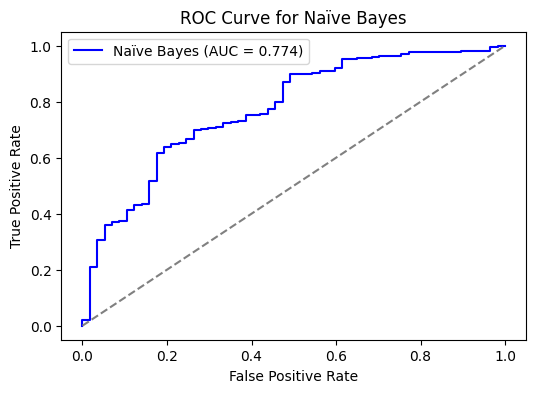

In [37]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Define explanatory variables 
explanatory_vars = ["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thick", "arac", "asex", "loc"]

# Define explanatory variables and response variable
X = mortgage_data[explanatory_vars]  # Ensure consistency
y = mortgage_data["approve"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict outcomes
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # Probability scores for ROC curve

# Evaluate model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Compute ROC curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Display results
print(f"Naïve Bayes Accuracy: {accuracy_nb:.4f}")
print("Confusion Matrix:\n", conf_matrix_nb)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr_nb, tpr_nb, color="blue", label=f"Naïve Bayes (AUC = {roc_auc_nb:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Naïve Bayes")
plt.legend()
plt.show()

## Support Vector Machines

The Support Vector Machine (SVM) classifier is a powerful machine-learning algorithm used for classification tasks, including **loan approval predictions**. The goal of SVM is to find the optimal decision boundary (also called a **hyperplane**) that maximally separates two classes: **approved** (`approve = 1`) and **denied** (`approve = 0`).

Unlike **Logit** and **LDA**, which assume linear relationships between features and outcomes, **SVM can capture more complex decision boundaries**, making it a strong alternative when data **is not perfectly separable**.


The **SVM optimization problem** aims to find the best separating hyperplane that maximizes the margin between approved and denied mortgage applicants. Mathematically, it is formulated as:

$$
\min_{w, b} \quad \frac{1}{2} ||w||^2
$$

To ensure correct classification, the model imposes the following constraints:

$$
Y_k (X_k w + b) \geq 1, \quad \forall k
$$

where:

| Symbol | Definition |
|---------|----------------|
| $ X_k $ | Predictor variables (features of mortgage applicants) |
| $ Y_k $ | Response variable (1 = approved, 0 = denied) |
| $ w $ | Weight vector (importance of each feature) |
| $ b $ | Bias (intercept) term |

The goal here is to **maximize the margin** between the two classes (approved vs. denied). The constraint ensures that **approved applicants** fall on one side of the hyperplane and **denied applicants** on the other. The **hyperplane** is defined by $ X_k w + b = 0 $, and SVM finds the optimal $ w $ and $ b $ to ensure correct classification.

Now, let's fit an **SVM classifier** to our mortgage approval dataset and evaluate its performance:

✅ SVM Model Accuracy: 0.8568
🔷 Confusion Matrix:
[[  0  57]
 [  0 341]]


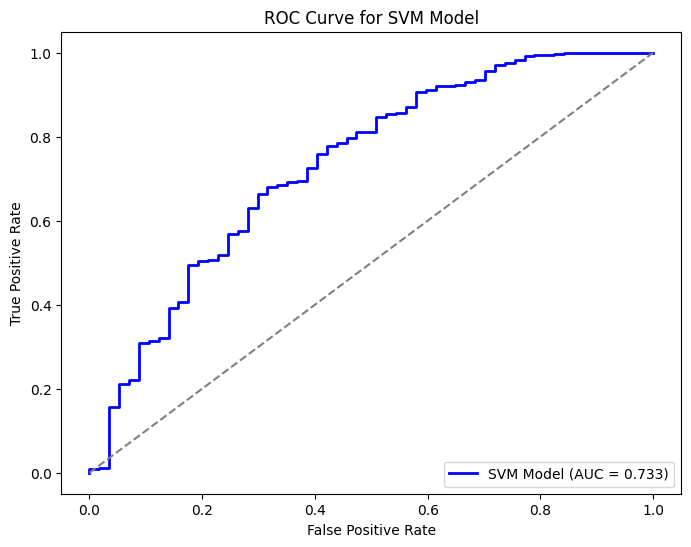

In [38]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Define explanatory variables and response variable
X = mortgage_data[["hrat", "obrat", "mhist", "pub", "self", "chist", "uemp", "multi", 
                    "cosign", "ms", "lnpr", "dep", "sch", "thick", "arac", "asex", "loc"]]
y = mortgage_data["approve"]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model (linear kernel)
svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)
y_pred_prob_svm = svm_model.predict_proba(X_test)[:,1]

# Compute accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"✅ SVM Model Accuracy: {svm_accuracy:.4f}")

# Compute confusion matrix
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
print(f"🔷 Confusion Matrix:\n{svm_conf_matrix}")

# Compute ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_svm)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"SVM Model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for SVM Model")
plt.legend(loc="lower right")
plt.show()

> At this point, you may notice that **SVM** is **taking longer to run** compared to the other classification models we’ve implemented so far. This is completely normal. SVM is computationally more intensive because it searches for the optimal hyperplane that best separates approved and denied loan applicants. Since our dataset has 17 explanatory variables and nearly 2000 observations, this optimization process can take some time.

## Comparison of Classification Models

Now that we have successfully implemented and evaluated five classification models—**Linear Probability Model (LPM)**, **Logistic Regression (Logit)**, **Linear Discriminant Analysis (LDA)**, **Naïve Bayes**, and **Support Vector Machine (SVM)**—it’s time to compare their effectiveness.

Each model approaches the mortgage approval decision differently:

- **LPM** provides a simple interpretation but is limited as it does not constrain probabilities within [0,1].
- **Logit regression** improves on LPM by ensuring probability predictions fall within a valid range.
- **LDA** assumes normality in predictor variables and constructs a linear decision boundary.
- **Naïve Bayes** leverages Bayes' Theorem with an independence assumption.
- **SVM** finds the optimal separating hyperplane to classify loan approvals.

We will **compare their accuracy**, **confusion matrices**, and **AUC-ROC** scores to determine **which model** performs best for predicting mortgage approvals.


In [39]:
# Initialize lets-plot for rendering
LetsPlot.setup_html()

# Collect extracted performance metrics
models = ["LPM", "Logit", "LDA", "Naïve Bayes", "SVM"]
accuracy_scores = [lpm_accuracy, accuracy, lda_accuracy, accuracy_nb, svm_accuracy]
auc_scores = [lpm_auc, roc_auc, roc_auc, roc_auc_nb, roc_auc]

# Convert values to DataFrame
df = pd.DataFrame({
    "Model": models * 2,
    "Metric": ["Accuracy"] * 5 + ["AUC-ROC"] * 5,
    "Value": accuracy_scores + auc_scores
})

# Round values for better visualization
df["Value"] = df["Value"].round(3)

# Correct position of labels using dodge position to align them on their respective bars
p = ggplot(df, aes(x="Model", y="Value", fill="Metric")) + \
    geom_bar(stat="identity", position=position_dodge(width=0.8), show_legend=True) + \
    scale_fill_manual(values=["#2a9d8f", "#e76f51"]) + \
    ggtitle("Performance Comparison of Classification Models") + \
    xlab("Models") + ylab("Performance Score") + \
    theme_minimal() + \
    ggsize(1000, 500) + \
    geom_text(aes(label="Value", group="Metric"),
              position=position_dodge(width=0.8),  # Ensures correct positioning
              vjust=-0.3, 
              size=12, 
              fontweight="bold", 
              color="black")

# Show the final visualization
p

### Multiple Choice Questions

**Question 1**:

If a bank cares more about **minimizing false positives** (approving bad loans), which model should it prioritize?

- A. The model with the highest AUC-ROC score, since it better distinguishes between approved and denied applicants.
- B. The model with the highest accuracy, since it makes the fewest mistakes overall.
- C. The model with the lowest false negative rate, because that’s more important than false positives.
- D. The model with the highest probability estimates, as it shows strong confidence in its predictions.

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**A** – AUC-ROC captures the model’s ability to distinguish between approved and denied loans. A high AUC-ROC ensures that the model does well across different probability thresholds, which is crucial when trying to reduce false positives (approving unqualified applicants).


**Question 2**:

You are training a **Naïve Bayes** model for mortgage approval classification. Fill in the missing code (`XXXXX`) to correctly initialize and fit the model:

- A. GaussianNB, GaussianNB
- B. NaiveBayes, NaiveBayes
- C. MultinomialNB, MultinomialNB
- D. DecisionTreeNB, DecisionTreeNB

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**A** GaussianNB, GaussianNB (GaussianNB is used when features are continuous, as in our dataset.)

In [ ]:
from sklearn.naive_bayes import XXXXX

# Initialize and fit the Naïve Bayes model
nb_model = XXXXX()
nb_model.fit(X_train, y_train)

**Question 3**:

You are implementing an **SVM classifier** for mortgage approval prediction. What should replace `XXXXX` in the following code snippet to ensure a **linear** decision boundary?

- A. "poly"
- B. "rbf"
- C. "sigmoid"
- D. "linear"

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**D** "linear"(We specified a linear hyperplane, so the kernel should be "linear".)

In [ ]:
from sklearn.svm import SVC

# Train SVM model
svm_model = SVC(kernel=XXXXX, probability=True)
svm_model.fit(X_train, y_train)

**Question 4**:

Which of the following best describes why **Linear Discriminant Analysis (LDA)** generally has lower variance compared to **Support Vector Machines (SVM)**?

- A. LDA assumes normal distribution and equal variance within classes, leading to a more stable decision boundary
- B. LDA uses an optimization technique that maximizes the margin between classes
- C. LDA is a non-parametric method that does not rely on probability distributions
- D. LDA is more sensitive to outliers than SVM

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**A** LDA assumes normal distribution and equal variance within classes, leading to a more stable decision boundary (This assumption makes LDA less flexible but more stable, leading to lower variance compared to SVM.)


**Question 5**:

You need to **extract** the accuracy score from a trained Logistic Regression model. What should replace XXXXX in the code below?

- A. accuracy_score(y_pred_logit, y_test)
- B. accuracy_score(y_test, y_pred_logit)
- C. logit_model.accuracy(y_test, y_pred_logit)
- D. logit_model.score(y_test, y_pred_logit)

<span style="background-color:#ffecec; color:#d63384; padding:2px 5px; border-radius:4px; font-family:monospace;">Solution</span>: 
**B** accuracy_score(y_test, y_pred_logit) (accuracy_score(y_test, y_pred_logit) correctly computes accuracy by comparing actual vs. predicted value


In [ ]:
from sklearn.metrics import accuracy_score

# Predict outcomes
y_pred_logit = logit_model.predict(X_test)

# Extract accuracy
logit_accuracy = XXXXX(XXXXX, XXXXX)

## Challenge Task

Now that you have explored various classification methods for mortgage approval, it's time to apply **your skills to a real-world challenge!**

**The Challenge: Used Car Auction Fraud Detection**

On Kaggle, the ["Don't Get Kicked!" Competition](https://www.kaggle.com/competitions/DontGetKicked/overview) challenges you to build a model that predicts whether a used car at auction will be a bad buy. Similar to our mortgage approval task, this competition involves classification modelling to distinguish between good and bad purchases based on vehicle characteristics.

**Your Task**:

- Explore the **dataset** and identify relevant **predictor variables** like we did for mortgage approval.
- Choose a **classification model**:
  - Logistic Regression (Logit)
  - Linear Discriminant Analysis (LDA)
  - Naïve Bayes
  - Support Vector Machine (SVM)

- **Compare models** based on **accuracy**, **AUC-ROC**, and **confusion matrices** as we did in this workshop.
- Optimize feature selection and preprocessing to improve model performance.
- Submit your predictions to **Kaggle's leaderboard** and see how you rank against other data scientists!

 Start by downloading the dataset from Kaggle, apply what you've learned, and share your insights! 


## Summary

In this session, we explored **classification modelling** using mortgage approval data. We began by **examining and preprocessing the dataset**, identifying missing variables, and ensuring consistency. We then implemented **five classification models: Linear Probability Model (LPM), Logistic Regression (Logit), Linear Discriminant Analysis (LDA), Naïve Bayes, and Support Vector Machine (SVM)**, evaluating their performance through **accuracy, confusion matrices, and AUC-ROC scores**.

Key takeaways include:

- **Logit and LDA** balanced accuracy and interpretability.
- **SVM** was robust but computationally intensive.
- **Naïve Bayes** was efficient but relied on strong independence assumptions.
- **LPM**, while simple, had limitations in probability estimation.
- **Accuracy vs. AUC trade-offs** highlight the importance of misclassification costs.

Throughout this process, you gained hands-on experience with:

1. **Data Preprocessing and Feature Engineering** – Handling missing data, defining new variables, and ensuring dataset compatibility with models.
2. **Model Implementation** – Understanding the theory and applying classification models in Python.
3. **Evaluating Model Performance** – Using accuracy and AUC-ROC scores to compare models and understand trade-offs.
4. **Interpreting Results** – Recognizing the importance of context when selecting the best model (e.g., considering false positives vs. false negatives).
5. **Practical Challenges in Classification** – Exploring real-world limitations of models and applying strategies to improve predictive power.

Finally, we introduced a real-world challenge through the Kaggle "Don't Get Kicked!" competition, encouraging you to apply your skills to a real dataset and refine your modelling approaches further.

Now, take these insights and keep exploring ways to enhance your classification models!